# New Orleans Business License Trends Analysis 

Exploratory Data Analysis of Occupational Business Licenses in New Orleans 

## Project Objective

The goal of this analysis is to explore trends in New Orleans business licenses, focusing on business type distribution, geographic patterns, and changes over time. 

This project demonstrates data cleaning, exploratory analysis, and visualization techniques used to uncover meaningful insights from real-world business data. 

## Tools Used

- Python
- Jupyter Notebook
- Pandas 
- NumPy 
- Matplotlib 
- Seaborn 

## Import Libraries

In [1]:
# Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping
import folium
from folium.plugins import HeatMap

# Display Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

## Loading Dataset

In [2]:
df = pd.read_csv('../active_occ_licenses_2025.csv')

df.head()

,BusinessAddress,BusinessName,BusinessPhone,BusinessStartDate,BusinessType,BusinessLicenseNumber,City,OwnerName,State,StreetDirection,StreetName,StreetNumber,StreetSuffix,Suite,Zip,LocationX,LocationY,Latitude,Longitude,Location
0,4532 MAGAZINE ST,OCTAVIA ART AND FILM,504-616-6202,2008-03-14,Art Dealers,102680731,NEW ORLEANS,PAMELA M BRYAN,LA,NaN,MAGAZINE,4532,ST,NaN,70115-1543,3670385.57,518674.04,29.920506,-90.103601,POINT (-90.10360111114565 29.92050622841199)
1,24740 MILL VALLEY WAY,ALLOHN DESIGNS,NaN,2018-05-14,Special Events-Other (Vendor),105032410,CARSON,AGBENYA ALLOHN,CA,NaN,MILL VALLEY,24740,WAY,NaN,90745-6454,0.00,0.00,0.000000,0.000000,POINT (0 0)
2,2555 VALENCE ST,LOUANGER,(503) 867-6923,2025-02-01,Bed & Breakfast Inns,106124978,NEW ORLEANS,LOUANGER,LA,NaN,VALENCE,2555,ST,NaN,70115-6341,3669444.11,524212.50,29.935763,-90.106386,POINT (-90.10638567129016 29.935762975538836)
3,650 S ROCHEBLAVE ST,NOLA FROZEN TIME PHOTOGRAPHY,(504) 892-3220,2025-03-27,"Photography Studios, Portrait",106022854,NEW ORLEANS,NOLA FROZEN TIME PHOTOGRAPHY L,LA,S,ROCHEBLAVE,650,ST,NaN,70119-7439,3674709.28,532565.42,29.958575,-90.089477,POINT (-90.0894771646702 29.958574674015836)
4,3317 MAGAZINE ST,A VARGAS BODY SHOP,504-891-2606,1980-02-03,"Automotive Body, Paint & Interior Repair & Mai...",101117693,NEW ORLEANS,A VARGAS BODY SHOP INC,LA,NaN,MAGAZINE,3317,ST,NaN,70115-2410,3675193.08,519773.31,29.923386,-90.088388,POINT (-90.08838832801506 29.923386122945704)


## Dataset Overview

In [3]:
df.shape
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10896 entries, 0 to 10895
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BusinessAddress        10896 non-null  object 
 1   BusinessName           8014 non-null   object 
 2   BusinessPhone          9594 non-null   object 
 3   BusinessStartDate      10896 non-null  object 
 4   BusinessType           10894 non-null  object 
 5   BusinessLicenseNumber  10896 non-null  int64  
 6   City                   10896 non-null  object 
 7   OwnerName              10896 non-null  object 
 8   State                  10896 non-null  object 
 9   StreetDirection        1382 non-null   object 
 10  StreetName             10855 non-null  object 
 11  StreetNumber           10858 non-null  object 
 12  StreetSuffix           10768 non-null  object 
 13  Suite                  1429 non-null   object 
 14  Zip                    10896 non-null  object 
 15  Lo

,BusinessAddress,BusinessName,BusinessPhone,BusinessStartDate,BusinessType,BusinessLicenseNumber,City,OwnerName,State,StreetDirection,StreetName,StreetNumber,StreetSuffix,Suite,Zip,LocationX,LocationY,Latitude,Longitude,Location
count,10896,8014,9594,10896,10894,1.089600e+04,10896,10896,10896,1382,10855,10858,10768,1429,10896,1.089600e+04,10896.000000,10896.000000,10896.000000,10896
unique,7812,7603,8454,4070,456,NaN,391,10172,44,15,1569,3499,57,491,5732,NaN,NaN,NaN,NaN,6426
top,1200 N PETERS ST,LUCKY COIN MACHINE CO,(000) 000-0000,2023-01-01,Special Events-Other (Vendor),NaN,NEW ORLEANS,LUCKY COIN MACHINE CO LLC,LA,N,MAGAZINE,701,ST,A,70116-0000,NaN,NaN,NaN,NaN,POINT (0 0)
freq,208,19,37,510,1034,NaN,10028,24,10480,745,484,265,6073,112,254,NaN,NaN,NaN,NaN,1443
mean,NaN,NaN,NaN,NaN,NaN,1.042894e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.186642e+06,463689.547583,25.994698,-78.162927,NaN
std,NaN,NaN,NaN,NaN,NaN,5.515451e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.254969e+06,181502.563677,10.156764,30.544022,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000009e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,0.000000,-100.005034,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.026781e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.669718e+06,522712.325000,29.930934,-90.086112,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.050146e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.679241e+06,530869.905000,29.953734,-90.067284,NaN
75%,NaN,NaN,NaN,NaN,NaN,1.050589e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.683793e+06,536682.512500,29.969726,-90.025534,NaN


## Business Type Distribution 
This section explores the distribution of active business licenses by business type to better understand the variety of industries operating in New Orleans. Counts are summarized and visualized using a bar chart, highlighting which business categories appear most frequently in the dataset. 

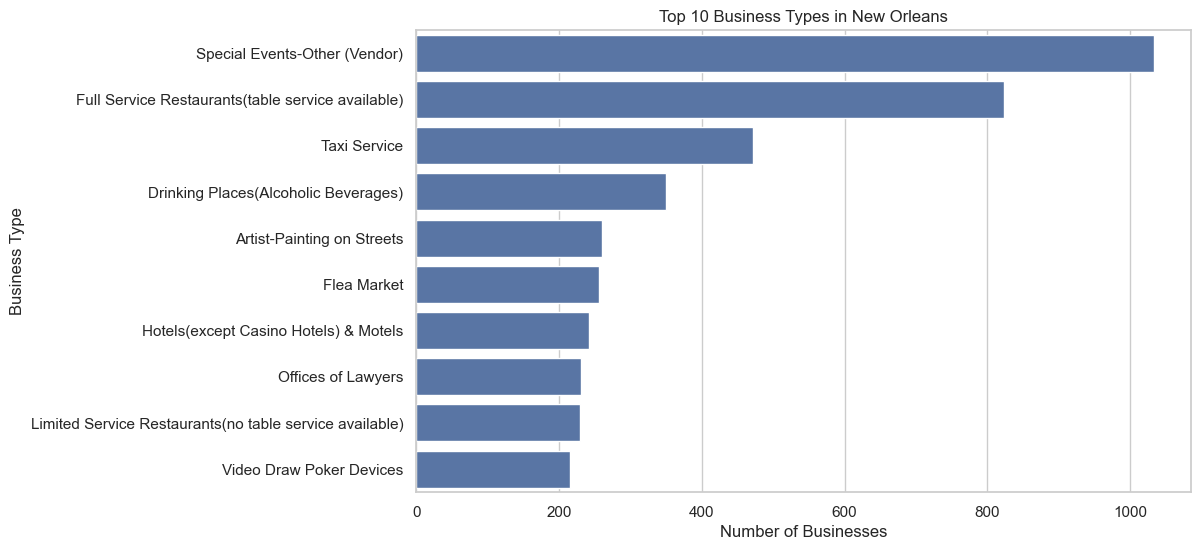

In [13]:
# Top 10 Overall Business Types 
top_business_types = df['BusinessType'].value_counts().head(10)

plt.figure(figsize = (10,6))
sns.barplot(
    x = top_business_types.values,
    y = top_business_types.index
)

plt.title("Top 10 Business Types in New Orleans")
plt.xlabel("Number of Businesses")
plt.ylabel("Business Type")
plt.savefig("../images/top_10_business_types.png", bbox_inches = 'tight', dpi = 300)
plt.show()

Special Events vendors appear most frequently among active licenses, suggesting a strong presence of event-based businesses in New Orleans. Restaurants, bars, and hospitality-related categories also rank highly, reflecting the city's tourism-driven economy.

## Business License Start Date Trends (2000-2025)
This section examines how business license registrations have changed over time, focusing specifically on the period from 2000 to 2025. Counts are aggregated by year and visualized to highlight trends in business formation, including periods of growth, stability, or decline across the city. 

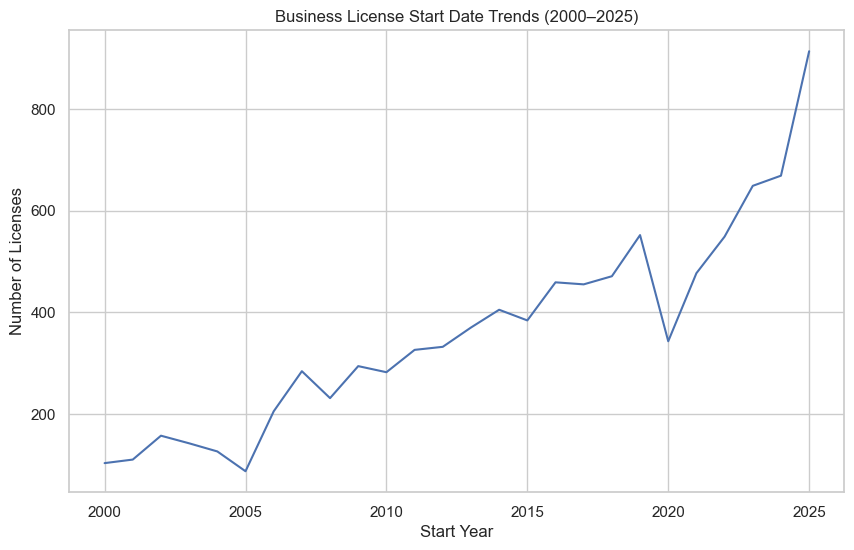

In [14]:
df['BusinessStartDate'] = pd.to_datetime(df['BusinessStartDate'], errors = 'coerce')
df['StartYear'] = df['BusinessStartDate'].dt.year

# Filtering Analysis Review to (2000–2025)
df_filtered = df[(df['StartYear'] >= 2000) & (df['StartYear'] <= 2025)]

year_counts = df_filtered['StartYear'].value_counts().sort_index()

plt.figure(figsize = (10,6))
plt.plot(year_counts.index, year_counts.values)
plt.title("Business License Start Date Trends (2000–2025)")
plt.xlabel("Start Year")
plt.ylabel("Number of Licenses")
plt.savefig("../images/business_starts_by_year.png", bbox_inches = 'tight', dpi = 300)
plt.show()

Business license registrations show a steady upward trend from 2000 to 2025, with strong growth beginning in the mid-2010s. This pattern suggests increasing business activity across New Orleans during the past two decades. 

## Most Common Business Names
This section explores which business names appear most frequently in the dataset. Counts are summarized and visualized, identifying businesses that operate multiple licensed locations or appear repeatedly across records. 

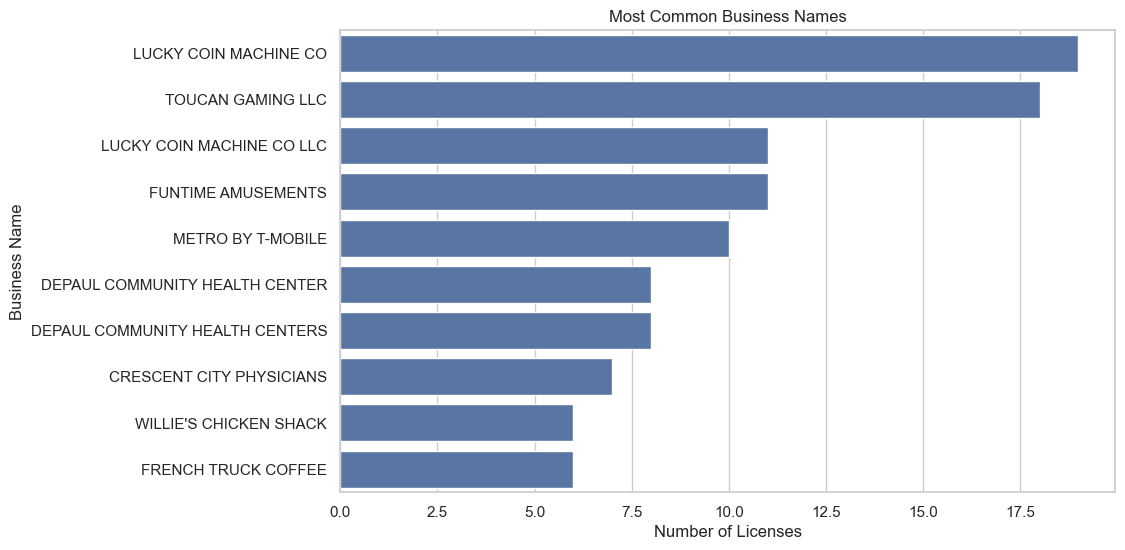

In [15]:
# Top 10 Business Names
top_business_names = df['BusinessName'].value_counts().head(10)

plt.figure(figsize = (10,6))
sns.barplot(
    x = top_business_names.values,
    y = top_business_names.index
)

plt.title("Most Common Business Names")
plt.xlabel("Number of Licenses")
plt.ylabel("Business Name")
plt.savefig("../images/top_business_names.png", bbox_inches = 'tight', dpi = 300)
plt.show()

Certain businesses appear multiple times in the dataset. This indicates organizations that operate several licensed locations or machines throughout the city. Gaming and amusement-related businesses appear prominently, suggesting a noticeable presence of these establishments within New Orleans. 

## Geographic Distribution of Businesses
This section explores the geographic distribution of licensed businesses across New Orleans. An interactive map is used to visualize areas where business activity is most concentrated throughout the city.

In [16]:
# Filtering to New Orleans bounding box, removing outliers and non-city records
df_map = df.dropna(subset = ["Latitude", "Longitude"])
df_map = df_map[(df_map["Latitude"] != 0) & (df_map["Longitude"] != 0)]
df_map = df_map[
    df_map["Latitude"].between(29.85, 30.10) &
    df_map["Longitude"].between(-90.20, -89.85)
]

m = folium.Map(location = [29.9511, -90.0715], zoom_start = 12)

HeatMap(
    df_map[["Latitude","Longitude"]].values,
    radius = 12,
    blur = 15,
    max_zoom = 13
).add_to(m)

m.save("../docs/business_density_map.html")
m

Business activity is concentrated in several key areas of New Orleans, particularly within central commercial districts and major business corridors. These clusters highlight locations where licensed businesses are most densely distributed across the city.

## Business Type Trends Over Time
This analysis explores how the most common business categories have evolved. Using data from 2000 onward, it focuses on the top business types and compares license counts by year, revealing long-term trends and shifts in industry activity. 

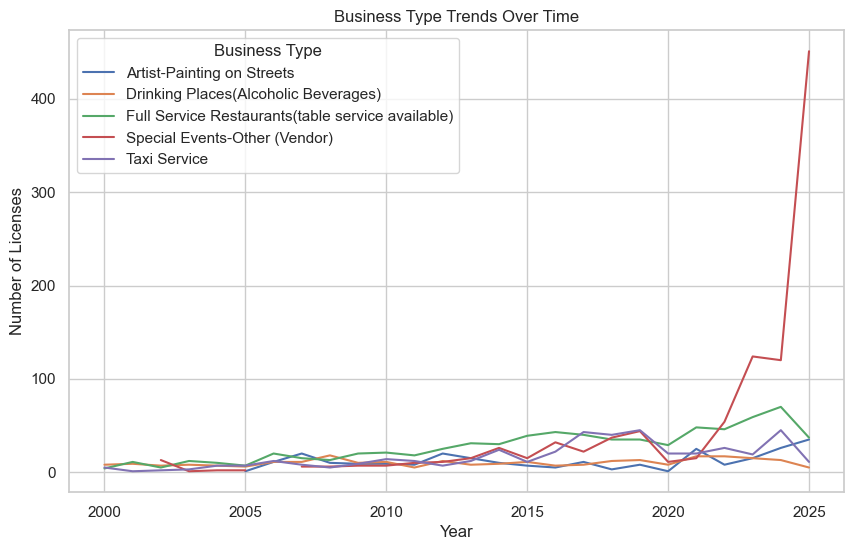

In [17]:
# Filtering Analysis Window (2000+)
filtered_years = df[df["StartYear"] >= 2000]
top_types = filtered_years["BusinessType"].value_counts().head(5).index


filtered_df = filtered_years[filtered_years["BusinessType"].isin(top_types)]
trend_data = filtered_df.groupby(["StartYear", "BusinessType"]).size().unstack()

plt.figure(figsize = (10,6))
trend_data.plot(ax = plt.gca())

plt.title("Business Type Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Licenses")
plt.legend(title = "Business Type")
plt.savefig("../images/business_type_trends_over_time.png", bbox_inches = 'tight', dpi = 300)
plt.show()

## Key Insights
- Business license registrations increased steadily from 2000 through 2025, indicating
  continued growth in local business activity across New Orleans.

- Vendor and event-related businesses show the most dramatic increase in recent years.
  This indicates expanding activity within temporary and event-based commerce.

- Service and hospitality categories, including restaurants and drinking establishments
  remain consistently represented among active licenses.

- Several businesses appear multiple times in the dataset, suggesting companies that
  operate multiple locations, machines, or franchises throughout the city.

- Business activity is geographically concentrated in major commercial and tourism
  areas. This highlights where licensed businesses are most densely distributed.

Overall, the analysis reveals consistent patterns in business activity over time, with certain industries demonstrating sustained growth while others remain stable or fluctuate, reflecting evolving economic and market dynamics in New Orleans. 